In [1]:
%load_ext autoreload
    
import xarray as xr
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
import cartopy.crs as ccrs
import sys
from acacia_s2s_toolkit.postprocess import get_example_data 
from acacia_s2s_toolkit.bias_correction import biascorrection

from acacia_s2s_toolkit.postprocess import *


In [2]:
# defining what you want to process - i.e. forecast date, domain and observed dataset

# nominal forecast date is defined here. 
# for testing and deve - I've been using data for different dates downlaoded with different enslags and fc_time
#"2026-09-15" - rc_enslags=[-1,1], fc_time=True
#"2026-09-10" - rc_enslags=[-1,1], fc_time=False
#"2026-09-12" - fc_enslags=[-1,-3], rc_enslags=[-1,1], fc_time=False
#"2026-09-06" - rf_enslags=[-1], fc_enslags=[-1], fc_time=False
"20260910"

data_dir="./data" #where data files are read from

nominal_date="2026-09-10" #date of the file - also treated here as the nominal date of the forecast, i.e. date for which forecast was requested.
target_domain="madagascar" #target domain
fcst_var="tp" #forecast variable
fcst_model="ECMWF" #forecast model
window_size=7 #size of the aggregation window



#this is file with observational data. It is gridded and covers the period of Jan 1981-March 2026
# any file with daily historical data should do, but if you don't have one at hand - you can get this one by:
#get_example_data(data_dir)
obs_file=f"{data_dir}/PRCPTOT_day_CHC_CHIRPS-2.0-0p25_merged.nc"

#we have to provide the name of the variable stored in the obs_file
obs_var="PRCPTOT"

# this is a file with vector data showing the boundaries of the domain - will be used in plotting only, so not strictly necessary
# this one is included in the example data that comes through get_example_data()
domain_shape_file=f"{data_dir}/madagascar.geojson"

# this defines regridding parameters for matching the obs and forecast grids. 
# it assumes obs grid is finer, so fine_to_coarse will give forecast grid, coarse_to_fine will give obs grid
# raise_if_missing will stop processing if the spatial overlap between obs and forecast grids of less than fractional 
# threshold
grid_alignment_kwargs=dict(
    direction="fine_to_coarse",
    method="conservative",
    raise_if_missing=True,
    threshold=0.9
)

# this defines time alignment parameter for matching the obs and hindcast time series. 
# raise_if_missing will stop processing if any of the hindcast days are not covered by observations 
time_alignment_kwargs={"raise_if_missing":True}

# this sets global verbosity variable. True will show runtime feedback 
set_verbose(False)

#deriving secondary parameters
fcst_date=pd.to_datetime(nominal_date)
fcst_date_str=fcst_date.strftime("%Y%m%d")

# constructing names of data files based on the information above
# forecast data file
fcst_file="{}/{}_{}_{}_{}_fc.nc".format(data_dir,fcst_var,fcst_model, fcst_date_str, target_domain)

# hindcast data file
hcst_file="{}/{}_{}_{}_{}_hc.nc".format(data_dir,fcst_var,fcst_model, fcst_date_str, target_domain)


verbosity is False


In [3]:
#=============================================================
# prelim stuff - reading and organizing data...
# one has to start with this in any pipeline

#reading forecast data - the read_netcdf() wraps xr.open_mfdataset() adding some checks
fcst_raw=read_netcdf(fcst_file, fcst_var)

#reading hindast
hcst_raw=read_netcdf(hcst_file, fcst_var)

# reading observed data
obs_raw=read_netcdf(obs_file, obs_var)

#this is not a part of the ultimate pipeline. It's here because files i have do not have enslag coordinate which is needed later
# once downloaded data have information about ensemble lag embedded in them - this will not be necessary
# if we adopt a different convention instead of enslag(member) coordinate - I will have to adapt functions that rely on its presence, but that's fine.
hcst_raw=add_enslag(hcst_raw, nominal_date)
fcst_raw=add_enslag(fcst_raw, nominal_date)

print("\n raw data")
print(f"nobs raw: {obs_raw.sizes}")
print(f"fcst raw: {fcst_raw.sizes}")
print(f"hcst raw: {hcst_raw.sizes}")

# converting accumulated to daily
# note that assumption here is that there is data for t=0, i.e. at initialization
# under this assumption - deaccumulation will drop one time step from each initialization cycle. 
# So forecast will lose 1 time step, but hindcast will lose as many time steps as there are hindcast years.
fcst_day=deaccumulate(fcst_raw)
hcst_day=deaccumulate(hcst_raw)

#just printing this to see shapes of each dataset
print("\n after deaccumulation")
print(f"fcst daily: {fcst_day.sizes}")
print(f"hcst daily: {hcst_day.sizes}")

#this aligns grids of forecast and observed - resampling upwards or downwards in scale depending on kwargs
obs_align,fcst_align=align_grid(obs_raw, fcst_day, **grid_alignment_kwargs)

#same for hindcast
#note that obs_align overwrites the previous one, but assumption is that forecast and hindcast are on the same grid
#obs_align has to be returned even if alignment is of hindcast/forecast to observed, because it will be modified (masked) in case there are masked areas in the forecast/hindcast data 
obs_align,hcst_align=align_grid(obs_raw, hcst_day, **grid_alignment_kwargs)

#again - printing shapes to illustrate what changes
print("\n after grid alignment")
print(f"obs aligned: {obs_align.sizes}")
print(f"fcst aligned: {fcst_align.sizes}")
print(f"hcst aligned: {hcst_align.sizes}")

#making sure times are aligned. Note that obs_tslice will have member dimension 
# and for each member will have obs data corresponding to hindcast
obs_ts,hcst_ts=align_time(obs_align, hcst_align, add_members=True, **time_alignment_kwargs)

#for consistency of object names:
fcst_ts=fcst_align.copy()

print("\n after time alignment")
print(f"obs time series: {obs_ts.sizes}")
print(f"fcst time series: {fcst_ts.sizes}")
print(f"hcst time series: {hcst_ts.sizes}")


 raw data
nobs raw: Frozen({'time': 16467, 'lat': 58, 'lon': 36})
fcst raw: Frozen({'time': 30, 'member': 101, 'lat': 11, 'lon': 7})
hcst raw: Frozen({'time': 640, 'member': 22, 'lat': 11, 'lon': 7})

 after deaccumulation
fcst daily: Frozen({'time': 29, 'member': 101, 'lat': 11, 'lon': 7})
hcst daily: Frozen({'time': 620, 'member': 22, 'lat': 11, 'lon': 7})

 after grid alignment
obs aligned: Frozen({'time': 16467, 'lat': 11, 'lon': 7})
fcst aligned: Frozen({'time': 29, 'member': 101, 'lat': 11, 'lon': 7})
hcst aligned: Frozen({'time': 620, 'member': 22, 'lat': 11, 'lon': 7})

 after time alignment
obs time series: Frozen({'time': 620, 'member': 22, 'lat': 11, 'lon': 7})
fcst time series: Frozen({'time': 29, 'member': 101, 'lat': 11, 'lon': 7})
hcst time series: Frozen({'time': 620, 'member': 22, 'lat': 11, 'lon': 7})


In [4]:
#=============================================================
#processing pipeline for bias-correction at DAILY TIME SCALE starts here...
# 
# what we will do is the following:
# 1) organize data by leadtime
# 2) run bias correction on blocks of daily data. 
#    This is done on blocks because there is assumption that bias is lead-time dependent but 
#    we cannot bias correct individual days because it is not THAT lead time dependent
# 3) bring daily bias-corrected data back to the valid-time structure
# 4) trimm the data so that we have equal ensemble size across valid time
# 5) aggregate daily data into blocks - weeks or 5 day blocks or whatever
#=============================================================

#this re-organizes data into (nominal_date, member, lead_time, lat, lon) structure
hcst_lt=organize_by_leadtime(hcst_ts, nominal_time=fcst_date)
fcst_lt=organize_by_leadtime(fcst_ts, nominal_time=fcst_date)
obs_lt=organize_by_leadtime(obs_ts, nominal_time=fcst_date)

print("\norganized by lead time:")
print(f"obs by leadtime: {obs_lt.sizes}")
print(f"fcst by leadtime: {fcst_lt.sizes}")
print(f"hcst by leadtime: {hcst_lt.sizes}")

#bias correcting daily data in 7-day blocks - window_size - defined in the beginning
# note that obs_bc is returned too because bias correction will trim leadtime to a multiple of window_size
# and we need to keep the obs and hcst data identical in shape
fcst_bc,hcst_bc,obs_bc=biascorrection(fcst_lt, hcst_lt, obs_lt, window_size=window_size, is_aggregated=False, method="qm-ecdf")

print("\nafter bias correction:")
print(f"obs bc: {obs_bc.sizes}")
print(f"fcst bias-corrected: {fcst_bc.sizes}")
print(f"hcst bias-corrected: {hcst_bc.sizes}")

#organize daily bias corrected data back to time format
#note that _bc was trimmed to the multiple of agg_time, so the time series is shorter than the original
# our original was 29, it was trimmed to 28 in each member (multiple of 7)
hcst_time=leadtime_to_time(hcst_bc)
fcst_time=leadtime_to_time(fcst_bc)
obs_time=leadtime_to_time(obs_bc)

print("\norganized by time (with gaps along member dimension for staggered hindcast):")
print(f"obs time: {obs_time.sizes}")
print(f"fcst time: {fcst_time.sizes}")
print(f"hcst time: {hcst_time.sizes}")

#move from time format to valid_time format
# with trim=True (defbestault) only the overlap of all members will be kept. with enslags of -1,1 - this cuts off 2 days of overlap
# so the resulting leadtime is 26 now
hcst_vt=organize_by_validtime(hcst_time, trim=True)
fcst_vt=organize_by_validtime(fcst_time, trim=True)
obs_vt=organize_by_validtime(obs_time, trim=True)

print("\norganized by valid_time,lead_time and trimmed:")
print(f"obs vt: {obs_vt.sizes}")
print(f"fcst vt: {fcst_vt.sizes}")
print(f"hcst vt: {hcst_vt.sizes}")

#finally aggregate in valid time
#note that the method is exendable, one can write a dedicated function, so it could be e.g. a number of rain days, or count of days above a threshld  etc 
# see aggregate() function in postprocess.py
#
hcst_agg=aggregate(hcst_vt, window_size=window_size, method="sum", dim="lead_time")
fcst_agg=aggregate(fcst_vt, window_size=window_size, method="sum", dim="lead_time")
obs_agg=aggregate(obs_vt, window_size=window_size, method="sum", dim="lead_time")

print("\naggregated to blocks:")
print(f"obs agg: {obs_agg.sizes}")
print(f"fcst agg: {fcst_agg.sizes}")
print(f"hcst agg: {hcst_agg.sizes}")


organized by lead time:
obs by leadtime: Frozen({'nominal_time': 20, 'lead_time': 29, 'member': 22, 'lat': 11, 'lon': 7})
fcst by leadtime: Frozen({'nominal_time': 1, 'lead_time': 29, 'member': 101, 'lat': 11, 'lon': 7})
hcst by leadtime: Frozen({'nominal_time': 20, 'lead_time': 29, 'member': 22, 'lat': 11, 'lon': 7})
Requested window size: 7, data has 29 lead times. the last two windows will be processed as one

after bias correction:
obs bc: Frozen({'nominal_time': 20, 'lead_time': 29, 'member': 22, 'lat': 11, 'lon': 7})
fcst bias-corrected: Frozen({'nominal_time': 1, 'lead_time': 29, 'member': 101, 'lat': 11, 'lon': 7})
hcst bias-corrected: Frozen({'nominal_time': 20, 'lead_time': 29, 'member': 22, 'lat': 11, 'lon': 7})

organized by time (with gaps along member dimension for staggered hindcast):
obs time: Frozen({'time': 620, 'member': 22, 'lat': 11, 'lon': 7})
fcst time: Frozen({'time': 29, 'member': 101, 'lat': 11, 'lon': 7})
hcst time: Frozen({'time': 620, 'member': 22, 'lat': 

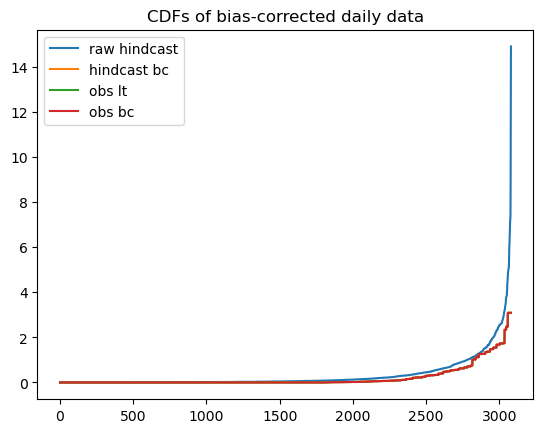

resample_agg: dropping last 6 step(s) of 'lead_time' (27 not divisible by window_size=7); keeping 21 steps.
resample_agg: dropping last 6 step(s) of 'lead_time' (27 not divisible by window_size=7); keeping 21 steps.


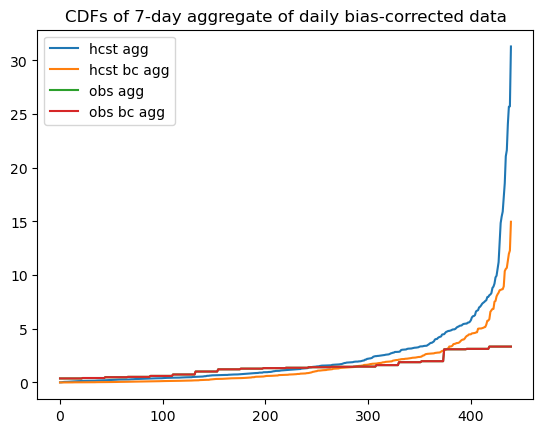

In [5]:
#=============================================================
# Illustrating how bias correction works
#=============================================================

#quick plot of daily data in the first week
plt.plot(np.sort(hcst_lt[:,0:7,:,4,4].data.flatten()), label="raw hindcast")
plt.plot(np.sort(hcst_bc[:,0:7,:,4,4].data.flatten()), label="hindcast bc")
plt.plot(np.sort(obs_lt[:,0:7,:,4,4].data.flatten()), label="obs lt")
plt.plot(np.sort(obs_bc[:,0:7,:,4,4].data.flatten()), label="obs bc")
plt.legend()
plt.title("CDFs of bias-corrected daily data")
plt.show()

# to illustrate what's happening with aggregare data - we need to aggregate the non-bias corrected data first, because it was not done in the pipeline above 

# so processing the raw data to get into the same time aggregate as that of biac-corrected data 
temp=leadtime_to_time(obs_lt)
temp=organize_by_validtime(temp, trim=True)
obs_raw_agg=aggregate(temp, window_size=window_size, method="sum", dim="lead_time")

#same for hindcast
temp=leadtime_to_time(hcst_lt)
temp=organize_by_validtime(temp, trim=True)
hcst_raw_agg=aggregate(temp, window_size=window_size, method="sum", dim="lead_time")

# note - bias correction in daily, does not ensure lack of bias in aggregated data
plt.plot(np.sort(hcst_raw_agg[:,0,:,4,4].data.flatten()),label="hcst agg")
plt.plot(np.sort(hcst_agg[:,0,:,4,4].data.flatten()),label="hcst bc agg")
plt.plot(np.sort(obs_raw_agg[:,0,:,4,4].data.flatten()), label="obs agg")
plt.plot(np.sort(obs_agg[:,0,:,4,4].data.flatten()), label="obs bc agg")
plt.title("CDFs of 7-day aggregate of daily bias-corrected data")
plt.legend()
plt.show()

In [6]:
#=============================================================
#processing pipeline for bias-correction of valid_time AGGREGATE starts here...
# 
# what we will do is the following:
# 1) we organize raw data by valid_time, trimming the lagged ensemble members
# 2) aggregate raw into block - weeks or 5 day blocks or whatever
# 3) run bias correction on block aggregates. 
#    Voila!
#=============================================================

# we start with these data - which are raw, grid and time aligned data
#
print("\nstarting with these data:")
print(f"obs: {obs_ts.sizes}")
print(f"hcst: {hcst_ts.sizes}")
print(f"fcst: {fcst_ts.sizes}")

#move from time format to valid_time format
# with trim=True (default) only the overlap of all members will be kept. with enslags of -1,1 - this cuts off 2 days of overlap
# this will reduce lead time to the duration of overlap
hcst_vt=organize_by_validtime(hcst_ts, trim=True)
fcst_vt=organize_by_validtime(fcst_ts, trim=True)
obs_vt=organize_by_validtime(obs_ts, trim=True, drop_member=False)

print("\norganizing by valid_time and trimming:")
print(f"obs by valid time: {obs_vt.sizes}")
print(f"hcst by valid time: {hcst_vt.sizes}")
print(f"fcst by valid time: {fcst_vt.sizes}")

obs_agg=aggregate(obs_vt,  window_size, "sum")
hcst_agg=aggregate(hcst_vt, window_size, "sum")
fcst_agg=aggregate(fcst_vt,  window_size, "sum")

print("\naggregated data:")
print(f"obs aggregated: {obs_agg.sizes}")
print(f"hcst aggregated: {hcst_agg.sizes}")
print(f"fcst aggregated: {fcst_agg.sizes}")

#here window size=1 and is_aggregated=True
# and we will try the methods implemented so far
fcst_bc1,hcst_bc1, obs_bc1=biascorrection(fcst_agg, hcst_agg, obs_agg, window_size=1, is_aggregated=True, method="qm-gamma")
fcst_bc2,hcst_bc2, obs_bc2=biascorrection(fcst_agg, hcst_agg, obs_agg, window_size=1, is_aggregated=True, method="qm-kde")
fcst_bc3,hcst_bc3, obs_bc3=biascorrection(fcst_agg, hcst_agg, obs_agg, window_size=1, is_aggregated=True, method="qm-ecdf")
fcst_bc4,hcst_bc4, obs_bc3=biascorrection(fcst_agg, hcst_agg, obs_agg, window_size=1, is_aggregated=True, method="scaling")


print("\nafter bias-correction:")
print(f"obs aggregated bc: {obs_bc1.sizes}")
print(f"hcst aggregated bc: {hcst_bc1.sizes}")
print(f"fcst aggregated bc: {fcst_bc1.sizes}")


starting with these data:
obs: Frozen({'time': 620, 'member': 22, 'lat': 11, 'lon': 7})
hcst: Frozen({'time': 620, 'member': 22, 'lat': 11, 'lon': 7})
fcst: Frozen({'time': 29, 'member': 101, 'lat': 11, 'lon': 7})

organizing by valid_time and trimming:
obs by valid time: Frozen({'valid_time': 20, 'lead_time': 27, 'member': 22, 'lat': 11, 'lon': 7})
hcst by valid time: Frozen({'valid_time': 20, 'lead_time': 27, 'member': 22, 'lat': 11, 'lon': 7})
fcst by valid time: Frozen({'valid_time': 1, 'lead_time': 29, 'member': 101, 'lat': 11, 'lon': 7})
resample_agg: dropping last 6 step(s) of 'lead_time' (27 not divisible by window_size=7); keeping 21 steps.
resample_agg: dropping last 6 step(s) of 'lead_time' (27 not divisible by window_size=7); keeping 21 steps.
resample_agg: dropping last 1 step(s) of 'lead_time' (29 not divisible by window_size=7); keeping 28 steps.

aggregated data:
obs aggregated: Frozen({'valid_time': 20, 'lead_time': 3, 'member': 22, 'lat': 11, 'lon': 7})
hcst aggregat

6.067023
6.070103427248073


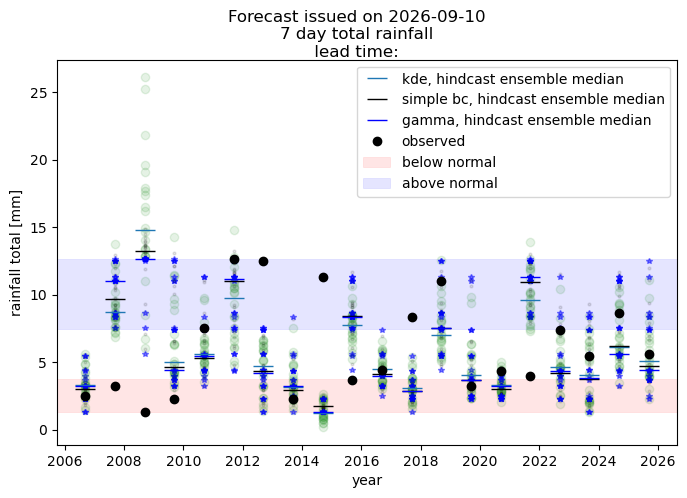

In [8]:
hindcast1=hcst_bc1.copy()
observed=obs_bc1.copy().isel(member=0).drop_vars("member")
hindcast2=hcst_bc2.copy()
hindcast3=hcst_bc3.copy()

# time series can be visualized for a selected location

# here we will use a location
lat,lon=-19,47.5

#we will plot it for a selected lead time
lead_time=0


# we use bias corrected forecast
hcst1=hindcast1.sel(lead_time=lead_time, lat=lat, lon=lon, method="nearest")
hcst2=hindcast2.sel(lead_time=lead_time, lat=lat, lon=lon, method="nearest")
hcst3=hindcast3.sel(lead_time=lead_time, lat=lat, lon=lon, method="nearest")

print(hcst1.mean(["valid_time","member"]).data)
      
#and observations in the lead-time oriented format
obs=observed.sel(lead_time=lead_time, lat=lat, lon=lon, method="nearest")

print(obs.mean(["valid_time"]).data)

#now plotting
fig=plt.figure(figsize=(8,5))

pl=fig.add_subplot(1,1,1)

#plotting hincasts - individual members
for m in hcst1.member:
    pl.plot(hcst1.valid_time,hcst1.sel(member=m), "o", color="green", alpha=0.1)
    pl.plot(hcst2.valid_time,hcst2.sel(member=m), "o", color="black", alpha=0.1, markersize=2)
    pl.plot(hcst3.valid_time,hcst3.sel(member=m), "*", color="blue", alpha=0.5, markersize=4)

#and hindcast median
pl.plot(hcst1.valid_time, hcst1.median("member"), "_", ms=15, label="kde, hindcast ensemble median")
pl.plot(hcst2.valid_time, hcst2.median("member"), "_", ms=15, color="black", label="simple bc, hindcast ensemble median")
pl.plot(hcst3.valid_time, hcst3.median("member"), "_", ms=15, color="blue", label="gamma, hindcast ensemble median")


#plotting observations
pl.plot(obs.valid_time,obs, "o", color="black", label="observed")

#adding terciles
pl.axhspan(obs.quantile(0.0), obs.quantile(0.33), label="below normal", color="red", alpha=0.1, lw=0.5)
pl.axhspan(obs.quantile(0.66), obs.quantile(1), label="above normal", color="blue", alpha=0.1, lw=0.5)


plt.suptitle("Forecast issued on {}\n{} day total rainfall\n lead time: ".format(nominal_date, window_size, lead_time))

pl.set_xlabel("year")
pl.set_ylabel("rainfall total [mm]")
plt.legend()
plt.show()